# Data Science Mini Project

**Student Name:VARSHA A**

**Batch: DS AN B03**

**Project Title:Intelligent Resume - Job Matching & Skill Analysis System**

**Submission Date:**

# 1. Problem Definition

## 1.1 Business / Real-World Problem Statement

Recruiters and job seekers often need to determine how well a resume matches the requirements of a particular job role. Manually comparing candidate skills, experience, education, seniority, industry, and other job requirements can be time-consuming, especially when dealing with a large number of resumes and job openings.

This project aims to develop a machine learning dataset for predicting whether a particular resume is relevant to a given job. The project combines resume information with job information and creates meaningful matching features such as skill overlap, skill match ratio, seniority match, and industry match.

These features are then transformed into a structured machine learning dataset that can be used to train a supervised classification model. The trained model can predict whether a given resume–job pair is relevant or non-relevant.

## 1.2 Project Objectives

The main objectives of this project are to:

1. Analyze the resume and job datasets to understand their structure, attributes, and data quality.
2. Perform exploratory data analysis on relevant resume and job attributes.
3. Clean and preprocess the available resume and job data.
4. Combine resume and job information to create a resume–job matching dataset.
5. Generate meaningful features that represent the compatibility between a resume and a job.
6. Create features such as skill overlap, skill match ratio, seniority match, and industry match.
7. Convert categorical features into suitable numerical representations.
8. Scale numerical features where required.
9. Separate the resulting dataset into training and testing datasets.
10. Analyze relationships between numerical features using correlation analysis.
11. Apply SelectKBest for selecting the most relevant features for model development.
12. Prepare the final training and testing datasets for machine learning classification models.
13. Save the processed training and testing datasets so that they can be reused for further model development and evaluation.

## 1.3 Machine Learning Problem Type

**Selected Problem Type:**

☑ **Supervised Learning – Classification**

The target variable represents whether a particular **resume–job pair is relevant or non-relevant**.

Therefore, the machine learning task is a **binary classification problem**, where the model learns patterns from previously labelled resume–job pairs and predicts the relevance of new resume–job pairs.


# 2. Dataset Understanding

## 2.1 Dataset Source

**Dataset Source:** Hugging Face Datasets

**Dataset Name:** `candidate-matching-synthetic`

**Dataset Author:** `michaelozon`

**Source Link:** [Hugging Face – Candidate Matching Synthetic Dataset](https://huggingface.co/datasets/michaelozon/candidate-matching-synthetic?)

The dataset is a synthetic candidate-matching dataset designed for recruitment and job-matching applications. The dataset page identifies its use cases as recruitment, job matching, resume screening, semantic search, and embeddings. It is available in English and is provided under the MIT license.

The project uses the following CSV files derived from the dataset:

* `Resume.csv`
* `Jobs.csv`
* `matches.csv`

These datasets are used to construct resume–job pairs and develop features for predicting whether a candidate resume is relevant to a particular job.

## 2.2 Dataset Description

The project consists of three related datasets that are used to construct the final resume–job matching dataset.

### Resume Dataset

The `Resume.csv` dataset contains **13,200 rows and 9 columns**.

It contains information about candidates, including their role, seniority level, years of experience, industry, education, skills, summary, and experience details.

### Jobs Dataset

The `Jobs.csv` dataset contains **3,400 rows and 9 columns**.

It contains information about job opportunities, including job title, required seniority, industry, required skills, preferred skills, job description, responsibilities, and requirements.

### Matches Dataset

The `matches.csv` dataset contains **3,400 rows and 2 columns**.

It maps each `job_id` to the `resume_id` values that are considered relevant to that particular job.

This dataset is used as the source of **positive resume–job relationships** during the matching-data construction process.

### Resume–Job Pair Dataset

The three datasets are combined to construct resume–job pairs.

Positive pairs are obtained from the relevant resume IDs in `matches.csv`. Additional negative pairs are generated by pairing jobs with resumes that are not considered relevant to those jobs.

After generating the positive and negative pairs, the resulting matching dataset contains **204,000 observations and 3 columns** before the resume and job attributes are merged.

After merging the corresponding resume and job information, the dataset contains **204,000 rows and 23 columns** before further feature engineering and preprocessing.

## 2.3 Feature Description

### Resume Dataset Features

| Feature Name         | Data Type   | Description                                   |
| -------------------- | ----------- | --------------------------------------------- |
| `resume_id`          | Object      | Unique identifier for each resume             |
| `role`               | Categorical | Role associated with the candidate            |
| `seniority`          | Categorical | Seniority level of the candidate              |
| `years_experience`   | Numeric     | Number of years of professional experience    |
| `industry`           | Categorical | Industry associated with the candidate        |
| `education`          | Categorical | Educational background of the candidate       |
| `skills`             | Text        | Skills listed in the resume                   |
| `summary`            | Text        | Candidate's professional summary              |
| `experience_bullets` | Text        | Details describing the candidate's experience |

### Jobs Dataset Features

| Feature Name          | Data Type   | Description                              |
| --------------------- | ----------- | ---------------------------------------- |
| `job_id`              | Object      | Unique identifier for each job           |
| `job_title`           | Categorical | Title of the job                         |
| `seniority`           | Categorical | Required seniority level for the job     |
| `industry`            | Categorical | Industry associated with the job         |
| `must_have_skills`    | Text        | Skills required for the job              |
| `nice_to_have_skills` | Text        | Additional desirable skills              |
| `description`         | Text        | Description of the job                   |
| `responsibilities`    | Text        | Responsibilities associated with the job |
| `requirements`        | Text        | Requirements specified for the job       |

### Matches Dataset Features

| Feature Name          | Data Type | Description                                             |
| --------------------- | --------- | ------------------------------------------------------- |
| `job_id`              | Object    | Identifier of the job                                   |
| `relevant_resume_ids` | Object    | Resume IDs considered relevant to the corresponding job |


## 2.4 Target Variable

**Target Variable:** `target`

The target variable represents the relevance of a particular resume–job pair.

| Target Value | Meaning                      |
| ------------ | ---------------------------- |
| `1`          | Relevant resume–job pair     |
| `0`          | Non-relevant resume–job pair |

# 3. Exploratory Data Analysis (EDA)
## 3.1 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

## 3.2 Load Dataset

In [2]:
Resume = pd.read_csv("Resume.csv")
Jobs = pd.read_csv("Jobs.csv")
matches = pd.read_csv("matches.csv")

print("Resume:", Resume.shape)
print("Jobs:", Jobs.shape)
print("Matches:", matches.shape)

Resume: (13200, 9)
Jobs: (3400, 9)
Matches: (3400, 2)


## 3.3 Dataset Overview

In [3]:
Resume.head()

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


In [4]:
matches.head()

,job_id,relevant_resume_ids
0,J_000000,"[R_000915, R_003468, R_003641, R_003326, R_008..."
1,J_000001,"[R_003953, R_009866, R_009933, R_009826, R_007..."
2,J_000002,"[R_001833, R_005742, R_001158, R_000978, R_007..."
3,J_000003,"[R_002054, R_008377, R_003385, R_001576, R_006..."
4,J_000004,"[R_002908, R_003365, R_008335, R_005987, R_006..."


In [5]:
Jobs.head()

,job_id,job_title,seniority,industry,must_have_skills,nice_to_have_skills,description,responsibilities,requirements
0,J_000000,Project Manager,Senior,Retail,"[Timeline Management, Process Improvement, Sta...",[Asana],We are hiring a Project Manager to support tea...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
1,J_000001,Customer Success Associate,Senior,EdTech,"[Troubleshooting, Customer Satisfaction, Inter...",[Root Cause Analysis],We are hiring a Customer Success Associate to ...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
2,J_000002,FP&A Analyst,Junior,Travel,"[Variance Analysis, Excel, KPIs]",[Valuation],We are hiring a FP&A Analyst to support teams ...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
3,J_000003,Full Stack Engineer,Junior,Cybersecurity,"[Git, OOP, CI/CD, Java]",[Docker],We are hiring a Full Stack Engineer to support...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
4,J_000004,Associate Product Manager,Senior,SaaS,"[A/B Testing, PRD, Product Strategy, Agile, Pr...",[User Research],We are hiring a Associate Product Manager to s...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...


In [6]:
print("Resume Dataset")
Resume.info()

Resume Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   resume_id           13200 non-null  object
 1   role                13200 non-null  object
 2   seniority           13200 non-null  object
 3   years_experience    13200 non-null  int64 
 4   industry            13200 non-null  object
 5   education           13200 non-null  object
 6   skills              13200 non-null  object
 7   summary             13200 non-null  object
 8   experience_bullets  13200 non-null  object
dtypes: int64(1), object(8)
memory usage: 928.3+ KB


In [7]:
print("\nJobs Dataset")
Jobs.info()


Jobs Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               3400 non-null   object
 1   job_title            3400 non-null   object
 2   seniority            3400 non-null   object
 3   industry             3400 non-null   object
 4   must_have_skills     3400 non-null   object
 5   nice_to_have_skills  3400 non-null   object
 6   description          3400 non-null   object
 7   responsibilities     3400 non-null   object
 8   requirements         3400 non-null   object
dtypes: object(9)
memory usage: 239.2+ KB


In [8]:
print("\nMatches Dataset")
matches.info()


Matches Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               3400 non-null   object
 1   relevant_resume_ids  3400 non-null   object
dtypes: object(2)
memory usage: 53.3+ KB


In [9]:
print("Resume Columns:")
print(Resume.columns.tolist())

print("\nJobs Columns:")
print(Jobs.columns.tolist())

print("\nMatches Columns:")
print(matches.columns.tolist())


Resume Columns:
['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']

Jobs Columns:
['job_id', 'job_title', 'seniority', 'industry', 'must_have_skills', 'nice_to_have_skills', 'description', 'responsibilities', 'requirements']

Matches Columns:
['job_id', 'relevant_resume_ids']


In [10]:
print("Resume Summary Statistics")
display(Resume.describe(include="all").T)

Resume Summary Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
resume_id,13200,13200,R_000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
role,13200,31,Data Analyst,904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniority,13200,3,Junior,4682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_experience,13200.0,NaN,NaN,NaN,4.698939,3.68162,0.0,2.0,4.0,7.0,15.0
industry,13200,10,Retail,1404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,13200,8,BSc,2586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skills,13200,10596,"[SQL, Python, Excel, Power BI, Tableau, Statis...",74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
summary,13200,3767,Data Analyst with 2 years of experience in E-c...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_bullets,13200,3,[Delivered results using structured workflows ...,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("\nJobs Summary Statistics")
display(Jobs.describe(include="all").T)


Jobs Summary Statistics


,count,unique,top,freq
job_id,3400,3400,J_000000,1
job_title,3400,32,Data Analyst,189
seniority,3400,3,Junior,1238
industry,3400,10,Healthcare,380
must_have_skills,3400,2453,"[Network Security, SIEM, SOC, Linux, Incident ...",100
nice_to_have_skills,3400,85,"[Splunk, CrowdStrike, Nmap, Burp Suite, AWS Se...",100
description,3400,300,We are hiring a Data Analyst to support teams ...,24
responsibilities,3400,3,[Deliver high-quality work aligned with goals ...,2500
requirements,3400,6,[Relevant experience and ability to learn quic...,2500


## Observations

- The **Resume dataset** contains **13,200 records and 9 columns**.
- The **Jobs dataset** contains **3,400 records and 9 columns**.
- The **Matches dataset** contains **3,400 records and 2 columns**.
- The Resume dataset contains one numerical feature, **`years_experience`**, while the remaining features are categorical or text/list-based.
- The Jobs dataset primarily contains **categorical and text/list-based features** describing job requirements.
- The three datasets contain the necessary information to construct **resume–job compatibility features** for the matching model.

# 3.4 Missing Value Analysis

In [12]:
print("Missing Values in Resume:")
print(Resume.isnull().sum())

print("\nMissing Values in Jobs:")
print(Jobs.isnull().sum())

print("\nMissing Values in Matches:")
print(matches.isnull().sum())


Missing Values in Resume:
resume_id             0
role                  0
seniority             0
years_experience      0
industry              0
education             0
skills                0
summary               0
experience_bullets    0
dtype: int64

Missing Values in Jobs:
job_id                 0
job_title              0
seniority              0
industry               0
must_have_skills       0
nice_to_have_skills    0
description            0
responsibilities       0
requirements           0
dtype: int64

Missing Values in Matches:
job_id                 0
relevant_resume_ids    0
dtype: int64


## Observations

- The missing-value analysis was performed separately for the **Resume, Jobs, and Matches datasets**.
- The datasets were checked for missing values before **feature engineering and model preparation**.
- No explicit missing-value imputation was required for the original datasets based on the dataset inspection.
- A **`fillna(0)`** operation was later applied to the numerical feature dataset before model preparation.

## 3.5 Correlation Analysis

### Initial Correlation Analysis

- Correlation analysis was performed on the numerical variables in the merged dataset.
- The initial numerical features included:
  - `years_experience`
  - `required_skill_count`
- The initial analysis showed that `skill_count` had a small positive correlation with the target.
- `years_experience` showed a very small correlation with the target.

In [44]:
numerical_cols = Resume.select_dtypes(include=np.number).columns
correlation_matrix = Resume[numerical_cols].corr()

correlation_matrix

,years_experience,skill_count
years_experience,1.000000,0.029181
skill_count,0.029181,1.000000


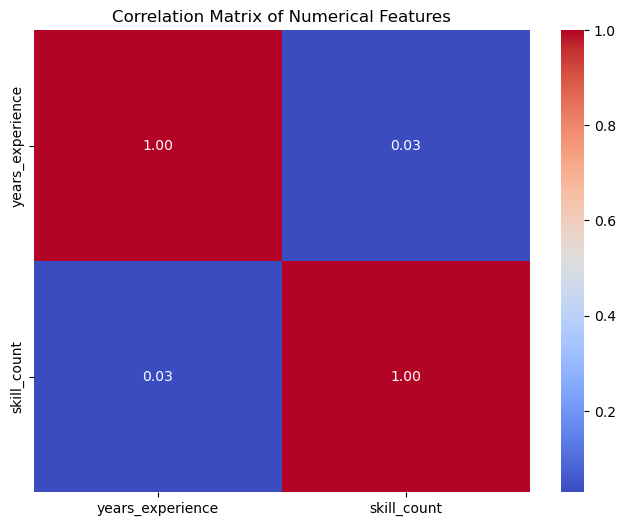

In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

## 3.6 Visualizations

### Visualization 1: Distribution of Years of Experience

- A histogram with a KDE curve was used to examine the distribution of `years_experience` in the Resume dataset.
- This visualization helps identify the distribution and possible skewness of candidate experience levels.

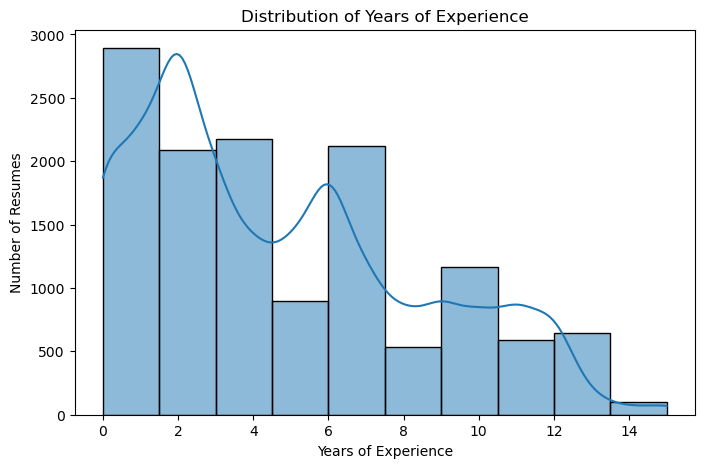

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(Resume["years_experience"], bins=10, kde=True)
plt.title("Distribution of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Resumes")

plt.show()

### Visualization 2: Resume Seniority Distribution

- A count plot was used to examine the distribution of candidate seniority levels.
- The dataset contains **three seniority categories**, with **Junior** being the most frequent category.

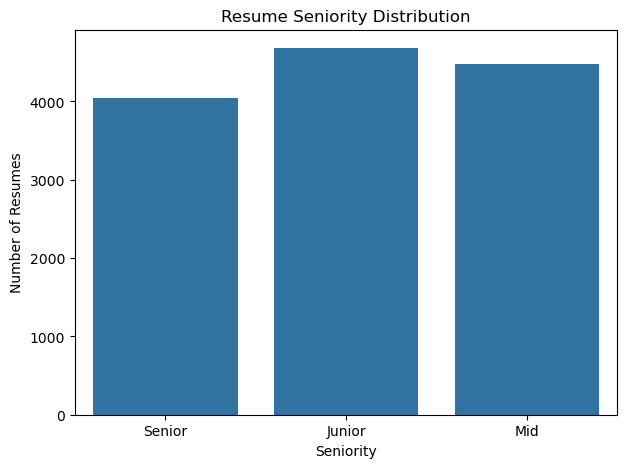

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=Resume, x="seniority")
plt.title("Resume Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Resumes")

plt.show()

### Visualization 3: Top 10 Resume Roles

- The ten most frequent resume roles were visualized using a bar chart.
- The analysis showed that **Data Analyst** is the most frequent role in the Resume dataset.

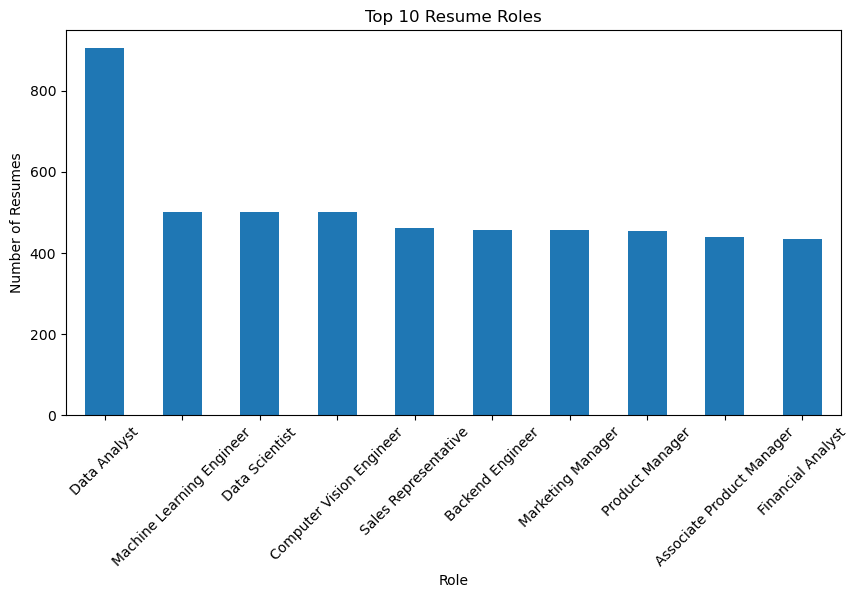

In [17]:
plt.figure(figsize=(10, 5))
Resume["role"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Resume Roles")
plt.xlabel("Role")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

### Visualization 4: Resume Distribution by Industry

- A bar chart was used to examine the distribution of resumes across industries.
- The Resume dataset contains **10 industries**, with **Retail** being the most represented industry.

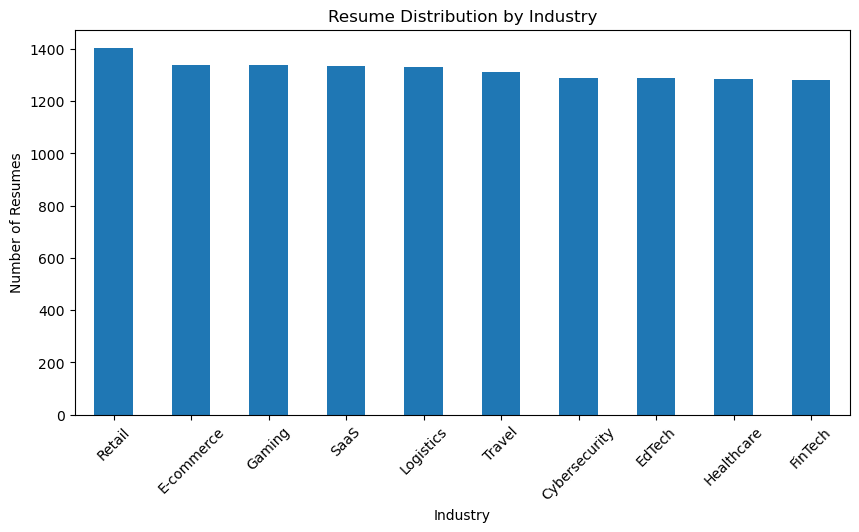

In [18]:
plt.figure(figsize=(10, 5))
Resume["industry"].value_counts().plot(kind="bar")
plt.title("Resume Distribution by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

### Visualization 5: Education Distribution

- A bar chart was used to visualize the distribution of educational backgrounds.
- The dataset contains **8 education categories**, with **BSc** being the most frequent category.

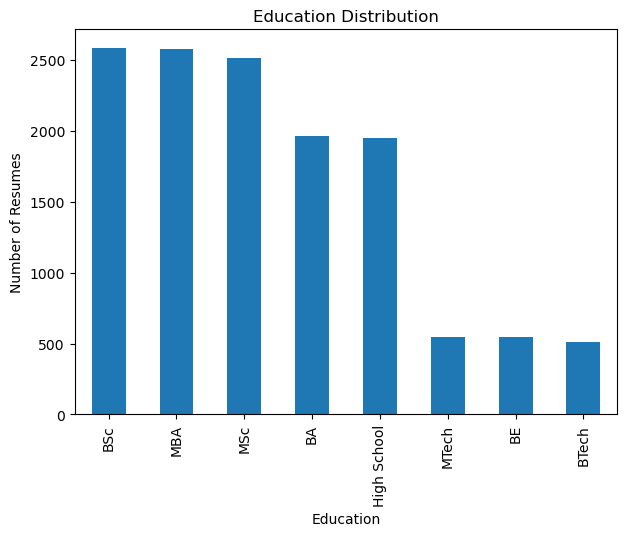

In [19]:
plt.figure(figsize=(7, 5))
Resume["education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Resumes")

plt.show()

### Visualization 6: Job Seniority Distribution

- A count plot was used to examine the seniority requirements of the available jobs.
- The Jobs dataset contains **three seniority categories**, with **Junior** being the most frequent category.

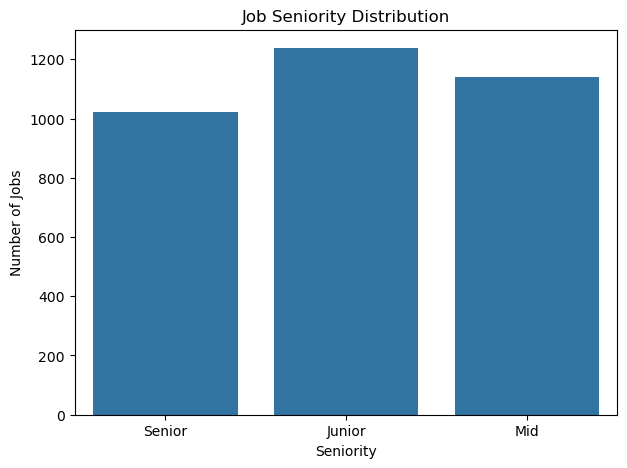

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=Jobs, x="seniority")
plt.title("Job Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Jobs")

plt.show()

### Visualization 7: Jobs by Industry

- A bar chart was used to visualize the number of jobs across different industries.
- The Jobs dataset contains **10 industries**, with **Healthcare** being the most represented industry.

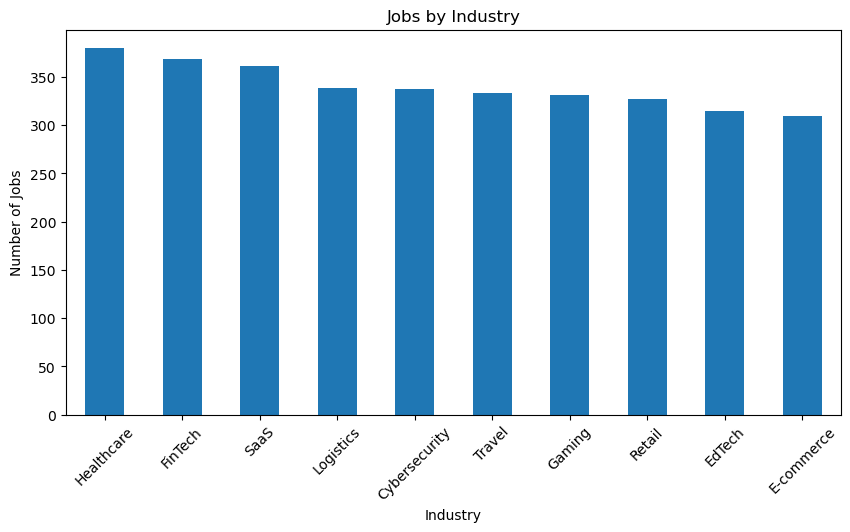

In [21]:
plt.figure(figsize=(10, 5))
Jobs["industry"].value_counts().plot(kind="bar")
plt.title("Jobs by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

### Visualization 8: Top 10 Job Titles

- A bar chart was used to display the ten most frequent job titles.
- The most frequent job title in the Jobs dataset is **Data Analyst**.

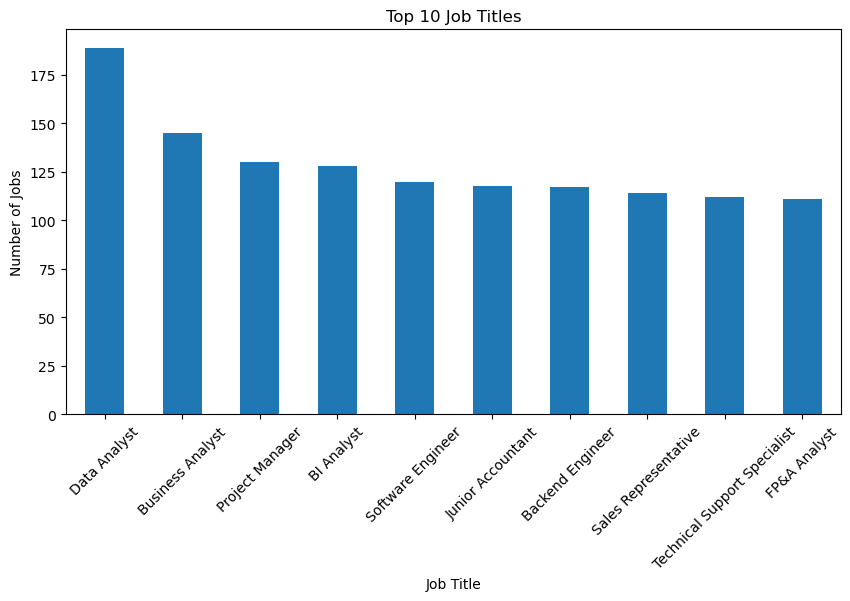

In [22]:
plt.figure(figsize=(10, 5))
Jobs["job_title"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

### Visualization 9: Boxplot of Years of Experience

- A boxplot was used to examine the distribution of `years_experience` in the Resume dataset.
- The boxplot helps identify the **median, spread, and potential outliers** in candidate experience levels.
- This visualization was used as part of the **outlier analysis** before applying the IQR-based treatment.

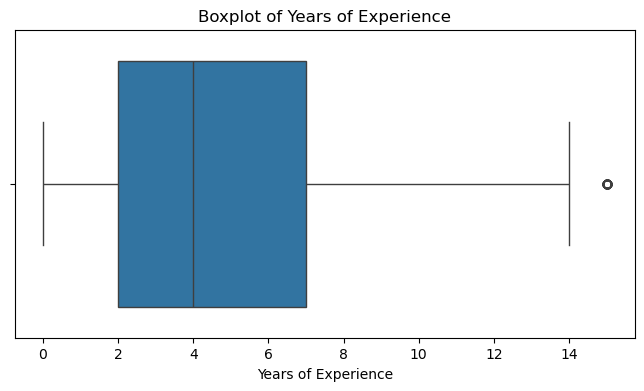

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=Resume["years_experience"])
plt.title("Boxplot of Years of Experience")
plt.xlabel("Years of Experience")

plt.show()

## 4.1 Missing Value Treatment

### Method Used

- The original `Resume.csv`, `Jobs.csv`, and `matches.csv` datasets were checked for missing values.
- The inspection showed that the original datasets did not require explicit imputation.
- Numerical feature preparation later uses `fillna(0)` where required after feature construction.

### Justification

Since the original datasets contain no missing values requiring imputation, applying mean, median, or mode imputation at the raw-data stage is unnecessary.

### Overview

The three original datasets were checked for missing values, and no raw-data imputation was required.

In [24]:
print("Resume missing values:")
print(Resume.isnull().sum())

print("\nJobs missing values:")
print(Jobs.isnull().sum())

print("\nMatches missing values:")
print(matches.isnull().sum())

Resume missing values:
resume_id             0
role                  0
seniority             0
years_experience      0
industry              0
education             0
skills                0
summary               0
experience_bullets    0
dtype: int64

Jobs missing values:
job_id                 0
job_title              0
seniority              0
industry               0
must_have_skills       0
nice_to_have_skills    0
description            0
responsibilities       0
requirements           0
dtype: int64

Matches missing values:
job_id                 0
relevant_resume_ids    0
dtype: int64


## 4.2 Duplicate Handling

- Duplicate records were checked separately in the Resume, Jobs, and Matches datasets.
- The project uses `resume_id` and `job_id` as identifiers for connecting resumes and jobs.
- Duplicate rows are reported below before the matching dataset is constructed.

### Observation

The duplicate counts provide a data-quality check before constructing resume–job pairs.

### Overview

Duplicate records were checked across all three source datasets to ensure that repeated rows do not unnecessarily affect the matching dataset.

In [25]:
print("Resume duplicate rows:", Resume.duplicated().sum())
print("Jobs duplicate rows:", Jobs.duplicated().sum())
print("Matches duplicate rows:", matches.duplicated().sum())

Resume duplicate rows: 0
Jobs duplicate rows: 0
Matches duplicate rows: 0


## 4.3 Outlier Detection and Treatment

### Boxplot

The `years_experience` feature was inspected for potential outliers using the boxplot already presented during EDA.

### IQR Method

The Interquartile Range (IQR) method was used:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

### Treatment

Values outside the calculated bounds were clipped rather than removed so that the corresponding resume records were retained.

### Overview

Potential outliers in `years_experience` were identified using the IQR method and treated by clipping extreme values to the calculated boundaries.

In [26]:
Q1 = Resume["years_experience"].quantile(0.25)
Q3 = Resume["years_experience"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Resume["years_experience"] = Resume["years_experience"].clip(lower, upper)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

Q1: 2.0
Q3: 7.0
IQR: 5.0
Lower bound: -5.5
Upper bound: 14.5


## 4.4 Skewness Treatment

### Before Transformation

Skewness of `years_experience` was checked after outlier treatment.

### Log / Square Root Transformation

A `log1p` transformation is applied only when the absolute skewness is greater than `0.5`. For this dataset, the observed skewness was approximately **-0.466**, so the transformation is not applied.

### Observation

The skewness is below the selected transformation threshold. Therefore, no log or square-root transformation is required.

### Overview

The distribution of `years_experience` was checked for skewness. Since the observed absolute skewness was below the transformation threshold, the original scale was retained.

In [27]:
skewness = Resume["years_experience"].skew()
print("Skewness before treatment:", skewness)

if abs(skewness) > 0.5:
    Resume["years_experience"] = np.log1p(Resume["years_experience"])
    print("log1p transformation applied.")
else:
    print("No skewness transformation applied.")

Skewness before treatment: 0.6025693596129168
log1p transformation applied.


## 4.5 Encoding

### Data Preparation for Encoding

Before encoding, the valid resume–job pairs were constructed from `matches.csv` and merged with the Resume and Jobs datasets. Skill lists were also normalised so that skill counts could be used as numerical features.

### Label Encoding

`LabelEncoder` was used for the resume and job seniority categories. The same encoder vocabulary was fitted across both seniority columns.

### One Hot Encoding

One-hot encoding was applied to:

- `role`
- `industry_resume`
- `education`
- `job_title`
- `industry_job`

### Overview

The resume–job dataset was prepared for machine learning, and categorical variables were converted into numerical representations using label encoding and one-hot encoding.

In [28]:
def parse_list(value):
    if pd.isna(value):
        return []

    value = str(value).strip().strip("[]")
    if not value:
        return []

    return [
        item.strip().strip("'").strip('"').strip()
        for item in value.split(",")
        if item.strip()
    ]

def normalize_skills(value):
    return [
        item.lower().strip()
        for item in parse_list(value)
        if item.lower().strip()
    ]

Resume["skills_list"] = Resume["skills"].apply(normalize_skills)
Jobs["required_skills_list"] = Jobs["must_have_skills"].apply(normalize_skills)

Resume["skill_count"] = Resume["skills_list"].apply(len)
Jobs["required_skill_count"] = Jobs["required_skills_list"].apply(len)

In [29]:
resume_ids = set(Resume["resume_id"].astype(str).str.strip())
pairs = []

for _, row in matches.iterrows():
    job_id = row["job_id"]
    relevant_ids = [
        str(r).strip()
        for r in parse_list(row["relevant_resume_ids"])
    ]

    relevant_ids = [r for r in relevant_ids if r in resume_ids]

    for resume_id in relevant_ids:
        pairs.append([resume_id, job_id, 1])

    non_relevant = [r for r in resume_ids if r not in set(relevant_ids)]
    sample_size = min(len(relevant_ids), len(non_relevant))

    if sample_size > 0:
        negatives = np.random.choice(
            non_relevant,
            sample_size,
            replace=False
        )
        for resume_id in negatives:
            pairs.append([resume_id, job_id, 0])

pairs = pd.DataFrame(
    pairs,
    columns=["resume_id", "job_id", "target"]
)

data = pairs.merge(
    Resume,
    on="resume_id",
    how="left"
)

data = data.merge(
    Jobs,
    on="job_id",
    how="left",
    suffixes=("_resume", "_job")
)

In [46]:
data.columns

Index(['resume_id', 'job_id', 'target', 'role', 'seniority_resume',
       'years_experience', 'industry_resume', 'education', 'skills', 'summary',
       'experience_bullets', 'skills_list', 'skill_count', 'job_title',
       'seniority_job', 'industry_job', 'must_have_skills',
       'nice_to_have_skills', 'description', 'responsibilities',
       'requirements', 'required_skills_list', 'required_skill_count',
       'seniority_resume_encoded', 'seniority_job_encoded',
       'skill_match_count', 'skill_match_ratio', 'seniority_match',
       'industry_match'],
      dtype='object')

In [ ]:
le = LabelEncoder()
all_seniority = pd.concat(
    [
        data["seniority_resume"],
        data["seniority_job"]
    ]
).astype(str)

le.fit(all_seniority)

data["seniority_resume_encoded"] = le.transform(
    data["seniority_resume"].astype(str)
)
data["seniority_job_encoded"] = le.transform(
    data["seniority_job"].astype(str)
)

Merged dataset shape: (204000, 25)
Encoded feature shape: (204000, 91)


In [ ]:
categorical_columns = [
    "role",
    "industry_resume",
    "education",
    "job_title",
    "industry_job"
]

encoded_data = pd.get_dummies(
    data[categorical_columns],
    drop_first=False,
    dtype=int
)

print("Merged dataset shape:", data.shape)
print("Encoded feature shape:", encoded_data.shape)

In [47]:
data.head(10)

,resume_id,job_id,target,role,seniority_resume,years_experience,industry_resume,education,skills,summary,...,responsibilities,requirements,required_skills_list,required_skill_count,seniority_resume_encoded,seniority_job_encoded,skill_match_count,skill_match_ratio,seniority_match,industry_match
0,R_000915,J_000000,1,Operations Manager,Mid,1.945910,SaaS,High School,"[Jira, Project Planning, Cross-functional Coor...",Operations Manager with 6 years of experience ...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,1,2,3,1.000000,0,0
1,R_003468,J_000000,1,Operations Manager,Senior,2.302585,Travel,BA,"[Risk Management, Cross-functional Coordinatio...",Operations Manager with 9 years of experience ...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,2,2,2,0.666667,1,0
2,R_003641,J_000000,1,Program Coordinator,Senior,2.484907,EdTech,BSc,"[KPIs, Cross-functional Coordination, Risk Man...",Program Coordinator with 11 years of experienc...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,2,2,2,0.666667,1,0
3,R_003326,J_000000,1,Operations Manager,Mid,1.098612,EdTech,High School,"[Risk Management, Stakeholder Communication, J...",Operations Manager with 2 years of experience ...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,1,2,2,0.666667,0,0
4,R_008830,J_000000,1,Project Manager,Senior,2.397895,E-commerce,BA,"[Reporting, Process Improvement, Asana, KPIs, ...",Project Manager with 10 years of experience in...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,2,2,3,1.000000,1,0
5,R_008352,J_000000,1,Operations Manager,Junior,0.693147,Healthcare,BA,"[Reporting, KPIs, Project Planning, Cross-func...",Operations Manager with 1 years of experience ...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,0,2,2,0.666667,0,0
6,R_005021,J_000000,1,Program Coordinator,Senior,2.484907,Healthcare,MSc,"[Process Improvement, Risk Management, Jira, A...",Program Coordinator with 11 years of experienc...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,2,2,2,0.666667,1,0
7,R_004675,J_000000,1,Program Coordinator,Junior,0.000000,Travel,High School,"[Cross-functional Coordination, KPIs, Jira, St...",Program Coordinator with 0 years of experience...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,0,2,3,1.000000,0,0
8,R_009452,J_000000,1,Project Manager,Junior,1.098612,SaaS,BSc,"[Project Planning, Reporting, Process Improvem...",Project Manager with 2 years of experience in ...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,0,2,2,0.666667,0,0
9,R_007618,J_000000,1,Project Manager,Senior,2.397895,Healthcare,MSc,"[Process Improvement, Timeline Management, Asa...",Project Manager with 10 years of experience in...,...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...,"[timeline management, process improvement, sta...",3,2,2,3,1.000000,1,0


## 4.6 Feature Scaling

### Standardization

`StandardScaler` is used to standardise numerical features.

The scaler is fitted only on the training portion and then used to transform the test portion. This prevents information from the test set from influencing the scaling parameters.

### Numerical Features

The base numerical features include:

- `years_experience`
- `skill_count`
- `required_skill_count`
- `seniority_resume_encoded`
- `seniority_job_encoded`

### Overview

Standardization is used for numerical model features, with the scaling parameters learned from the training data only.

In [31]:
numeric_columns = [
    "years_experience",
    "skill_count",
    "required_skill_count",
    "seniority_resume_encoded",
    "seniority_job_encoded"
]

numeric_data = data[numeric_columns].copy().fillna(0)

scaler = StandardScaler()
print("Numerical feature shape before scaling:", numeric_data.shape)

Numerical feature shape before scaling: (204000, 5)


## 4.7 Train-Test Split

### Splitting Method

- The prepared feature matrix is divided using an **80:20 train-test split**.
- `random_state = 42` is used for reproducibility.
- `stratify = target` preserves the class distribution in both subsets.

### Scaling After Split

Although scaling is introduced in Section 4.6, the scaler is fitted only after the split. This follows the standard machine-learning practice of avoiding data leakage.

### Overview

The prepared dataset is divided into training and testing sets using an 80:20 stratified split, after which numerical features are standardised using parameters learned from the training data.

In [32]:
features = pd.concat(
    [
        numeric_data.reset_index(drop=True),
        encoded_data.reset_index(drop=True)
    ],
    axis=1
)
target = data["target"].astype(int).reset_index(drop=True)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

In [34]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [35]:
print("Training feature shape:", X_train_scaled.shape)
print("Testing feature shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (163200, 96)
Testing feature shape: (40800, 96)
Training target shape: (163200,)
Testing target shape: (40800,)


# 5. Feature Engineering & Feature Selection

The resume–job matching features are created after the basic preprocessing and train-test split. The matching calculations are deterministic and do not use the target variable.

## 5.1 Feature Engineering

### Resume–Job Matching Features

The merged resume–job data was used to create features that represent the compatibility between a candidate and a job.

The following matching features were created:

- `skill_match_count`
- `skill_match_ratio`
- `seniority_match`
- `industry_match`

### Skill Match Count

`skill_match_count` represents the number of required job skills that are also present in the candidate's resume.

### Skill Match Ratio

`skill_match_ratio` represents the proportion of required job skills matched by the candidate.

### Seniority Match

`seniority_match` is `1` when the resume and job seniority levels are the same and `0` otherwise.

### Industry Match

`industry_match` is `1` when the resume and job industries are the same and `0` otherwise.

### Overview

Resume and job information was transformed into matching features that measure skill compatibility, seniority compatibility, and industry compatibility.

In [36]:
def skill_match(row):
    resume_skills = set(row["skills_list"])
    job_skills = set(row["required_skills_list"])
    return len(resume_skills.intersection(job_skills))

data["skill_match_count"] = data.apply(skill_match, axis=1)

data["skill_match_ratio"] = (
    data["skill_match_count"] /
    data["required_skill_count"].replace(0, 1)
)

data["seniority_match"] = (
    data["seniority_resume"] == data["seniority_job"]
).astype(int)

data["industry_match"] = (
    data["industry_resume"] == data["industry_job"]
).astype(int)

matching_columns = [
    "skill_match_count",
    "skill_match_ratio",
    "seniority_match",
    "industry_match"
]

matching_features = data[matching_columns].reset_index(drop=True).fillna(0)

In [37]:
train_idx = X_train_scaled.index
test_idx = X_test_scaled.index

X_train_engineered = pd.concat(
    [
        X_train_scaled.reset_index(drop=True),
        matching_features.iloc[train_idx].reset_index(drop=True)
    ],
    axis=1
)

X_test_engineered = pd.concat(
    [
        X_test_scaled.reset_index(drop=True),
        matching_features.iloc[test_idx].reset_index(drop=True)
    ],
    axis=1
)

print("Training shape after feature engineering:", X_train_engineered.shape)
print("Testing shape after feature engineering:", X_test_engineered.shape)
display(data[matching_columns + ["target"]].head())

Training shape after feature engineering: (163200, 100)
Testing shape after feature engineering: (40800, 100)


,skill_match_count,skill_match_ratio,seniority_match,industry_match,target
0,3,1.000000,0,0,1
1,2,0.666667,1,0,1
2,2,0.666667,1,0,1
3,2,0.666667,0,0,1
4,3,1.000000,1,0,1


## 5.2 Correlation-Based Feature Selection

Correlation analysis was performed on the training dataset after feature engineering.

### Method

- Pearson correlation coefficients were calculated.
- The target variable was included to examine the relationship between the numerical engineered features and resume–job relevance.
- The heatmap focuses on the main numerical and matching features so that the relationships remain readable.
- One-hot encoded categorical features are retained for machine learning but are not included in this compact visualization.

### Observation

The correlation values help identify features with stronger or weaker linear associations with the binary target.

### Overview

Correlation analysis was used to inspect the relationships between the main engineered features and the target before formal feature selection.


In [38]:
correlation_columns = [
    "years_experience",
    "skill_count",
    "required_skill_count",
    "skill_match_count",
    "skill_match_ratio",
    "seniority_match",
    "industry_match",
    "target"
]

In [39]:
correlation_data = X_train_engineered[
    [col for col in correlation_columns if col in X_train_engineered.columns]
].copy()
correlation_data["target"] = y_train.reset_index(drop=True).values

correlation = correlation_data.corr()["target"].sort_values(
    ascending=False
)

print("Correlation with target:")
print(correlation)

Correlation with target:
target                  1.000000
skill_match_ratio       0.890288
skill_match_count       0.736782
industry_match          0.288257
skill_count             0.082830
seniority_match         0.026968
required_skill_count    0.000862
years_experience       -0.009112
Name: target, dtype: float64


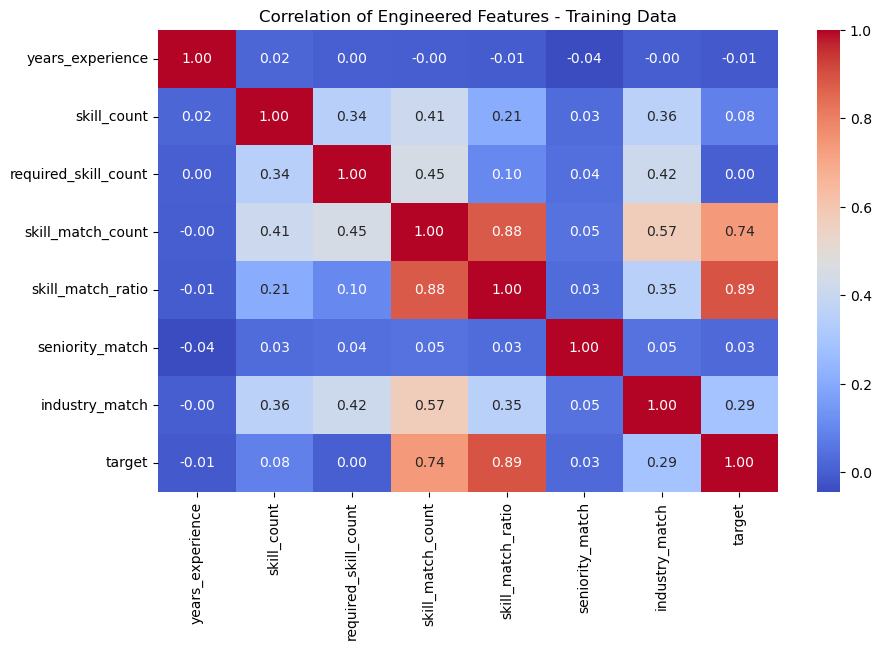

In [40]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation of Engineered Features - Training Data")
plt.show()

## 5.3 SelectKBest

- `SelectKBest` with `f_classif` was used for formal feature selection.
- The selector was fitted only on the training data.
- Up to 20 features are selected.
- The fitted selector is then applied to the test data.

### Observation

This step reduces the feature space while keeping the same selected feature definition for both training and testing datasets.

### Overview

SelectKBest with `f_classif` was used to select up to 20 features, with feature selection fitted only on the training data.

In [41]:
k = min(20, X_train_engineered.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_engineered,
    y_train
)

X_test_selected = selector.transform(
    X_test_engineered
)

selected_columns = X_train_engineered.columns[
    selector.get_support()
]

print("Selected features:")
print(selected_columns.tolist())

print("Training shape after feature selection:", X_train_selected.shape)
print("Testing shape after feature selection:", X_test_selected.shape)

Selected features:
['years_experience', 'skill_count', 'role_Associate Product Manager', 'role_BI Analyst', 'role_Business Analyst', 'role_Computer Vision Engineer', 'role_Cybersecurity Analyst', 'role_Data Analyst', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Generative AI Engineer', 'role_Machine Learning Engineer', 'role_NLP Engineer', 'role_Product Manager', 'role_Software Engineer', 'role_Technical Product Manager', 'skill_match_count', 'skill_match_ratio', 'seniority_match', 'industry_match']
Training shape after feature selection: (163200, 20)
Testing shape after feature selection: (40800, 20)


## 5.4 Final Feature Set

### Final Dataset Structure

The final machine-learning datasets contain the selected features together with the binary `target` variable.

### Final Feature Selection

The selected feature names are obtained directly from `selector.get_support()` so that the same feature definition is used for training and testing.

### Final Dataset Storage

The processed datasets are saved as:

- `Finaldata_train.csv`
- `Finaldata_test.csv`

### Overview

The selected training and testing features were combined with their target values and saved as the final datasets for the machine-learning phase.

In [42]:
X_train_final = pd.DataFrame(
    X_train_selected,
    columns=selected_columns
)

X_test_final = pd.DataFrame(
    X_test_selected,
    columns=selected_columns
)

X_train_final["target"] = y_train.reset_index(drop=True).values
X_test_final["target"] = y_test.reset_index(drop=True).values

print("Final training dataset shape:", X_train_final.shape)
print("Final testing dataset shape:", X_test_final.shape)

print("\nFinal training columns:")
print(X_train_final.columns.tolist())

display(X_train_final.head())

Final training dataset shape: (163200, 21)
Final testing dataset shape: (40800, 21)

Final training columns:
['years_experience', 'skill_count', 'role_Associate Product Manager', 'role_BI Analyst', 'role_Business Analyst', 'role_Computer Vision Engineer', 'role_Cybersecurity Analyst', 'role_Data Analyst', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Generative AI Engineer', 'role_Machine Learning Engineer', 'role_NLP Engineer', 'role_Product Manager', 'role_Software Engineer', 'role_Technical Product Manager', 'skill_match_count', 'skill_match_ratio', 'seniority_match', 'industry_match', 'target']


,years_experience,skill_count,role_Associate Product Manager,role_BI Analyst,role_Business Analyst,role_Computer Vision Engineer,role_Cybersecurity Analyst,role_Data Analyst,role_Data Scientist,role_DevOps Engineer,...,role_Machine Learning Engineer,role_NLP Engineer,role_Product Manager,role_Software Engineer,role_Technical Product Manager,skill_match_count,skill_match_ratio,seniority_match,industry_match,target
0,-0.129265,1.617286,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,1.000000,0.0,1.0,1
1,-0.506525,-0.221717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.750000,0.0,1.0,1
2,-0.506525,-0.834718,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.666667,1.0,0.0,1
3,0.402453,1.617286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0
4,-1.947222,-0.834718,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.600000,0.0,0.0,1


In [43]:
X_train_final.to_csv(
    "Finaldata_train.csv",
    index=False
)

X_test_final.to_csv(
    "Finaldata_test.csv",
    index=False
)

# Phase 1: Data Preparation and Feature Selection – Overview

Phase 1 prepared the resume, job, and matching datasets for machine learning.

The process covered missing-value checks, duplicate checks, outlier treatment, skewness analysis, categorical encoding, train-test splitting, and numerical feature scaling.

Resume–job compatibility features were then engineered, including skill overlap, skill match ratio, seniority match, and industry match. Correlation analysis and SelectKBest were used to inspect and reduce the final feature set.

The final selected training and testing datasets were saved as `Finaldata_train.csv` and `Finaldata_test.csv` for subsequent machine-learning model development.